In [28]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv(r"C:\Users\Bhargav\WEBSCRAPING-CLASSNOTES\WEB-SCRAPPING\Cars24-Project-data\Final_dataset.csv")

In [3]:
df['Location'] = df['Location'].str.strip().str.title()

print("Location after fixing:")
print(df['Location'].value_counts())

print("\nSample EMI values:")
print(df['EMI_per_Month'].value_counts().head(10))

df.drop('EMI_per_Month', axis=1, inplace=True)
print(" EMI_per_Month dropped (data leakage)")

df.drop('Status', axis=1, inplace=True)
print("Status dropped (not a price factor)")

print("\nSample Number values:")
print(df['Number'].value_counts().head(15))

rto_to_state = {
    'DL': 'Delhi',
    'HR': 'Haryana',
    'MH': 'Maharashtra',
    'KA': 'Karnataka',
    'TN': 'Tamil Nadu',
    'RJ': 'Rajasthan',
    'UP': 'Uttar Pradesh',
    'GJ': 'Gujarat',
    'TS': 'Telangana',
    'AP': 'Andhra Pradesh',
    'KL': 'Kerala',
    'PB': 'Punjab',
    'MP': 'Madhya Pradesh',
    'WB': 'West Bengal',
    'GA': 'Goa',
    'BR': 'Bihar'
}

df['State'] = df['Number'].str[:2].str.upper().map(rto_to_state)

print("\nState mapping result:")
print(df['State'].value_counts())
print(f"Unmapped (NaN): {df['State'].isnull().sum()}")

df['is_BH_series'] = df['Number'].str.upper().str.startswith('BH').astype(int)
print(f"\nBH Series cars: {df['is_BH_series'].sum()}")

df.drop('Number', axis=1, inplace=True)


city_to_state = {
    'Delhi':     'Delhi',
    'Bangalore': 'Karnataka',
    'Mumbai':    'Maharashtra',
    'Hyderabad': 'Telangana',
    'Pune':      'Maharashtra',
    'Ahmedabad': 'Gujarat',
    'Chennai':   'Tamil Nadu',
    'Gurgaon':   'Haryana'
}

df['State'] = df['State'].fillna(df['Location'].map(city_to_state))

print("\nState after filling from Location:")
print(df['State'].value_counts())
print(f"Still unmapped: {df['State'].isnull().sum()}")


df['Car_Age'] = 2025 - df['Year']
df.drop('Year', axis=1, inplace=True)

print("\nCar Age distribution:")
print(df['Car_Age'].value_counts().sort_index())


print("\nDriven_Kms stats:")
print(df['Driven_Kms'].describe())

df = df[(df['Driven_Kms'] > 500) & (df['Driven_Kms'] < 400000)]


print(f"\nUnique Variants: {df['Variant'].nunique()}")
print("Sample:", df['Variant'].head(10).tolist())

top_trim_keywords = [
    'ZXI', 'ZDI', 'ASTA', 'ALPHA', 'TITANIUM',
    'SPORTZ', 'PLUS', 'AT', 'AMT', 'CVT', 'DCT',
    'COMFORTLINE', 'HIGHLINE', 'TOPLINE', 'STYLE',
    'ELEGANCE', 'LUXURY', 'PREMIUM', 'TOP'
]

df['is_top_trim'] = df['Variant'].str.upper().apply(
    lambda x: 1 if any(kw in str(x) for kw in top_trim_keywords) else 0
)
print(f"\nTop trim: {df['is_top_trim'].sum()} cars")
print(f"Base trim: {(df['is_top_trim']==0).sum()} cars")

df.drop('Variant', axis=1, inplace=True)


print(f"\nUnique Brands: {df['Brand'].nunique()}")
print(df['Brand'].value_counts())

top_brands = df['Brand'].value_counts().nlargest(15).index
df['Brand'] = df['Brand'].apply(
    lambda x: x if x in top_brands else 'Other'
)
print("\nAfter grouping:")
print(df['Brand'].value_counts())


print(f"\nUnique Models: {df['Model'].nunique()}")
model_counts = df['Model'].value_counts()
df['Model'] = df['Model'].apply(
    lambda x: x if model_counts[x] >= 30 else 'Other'
)
print(f"After grouping: {df['Model'].nunique()} unique models")


df.rename(columns={'Price(In_Lakhs)': 'Price_In_Lakhs'}, inplace=True)

df.dropna(subset=['Price_In_Lakhs'], inplace=True)

Q1  = df['Price_In_Lakhs'].quantile(0.25)
Q3  = df['Price_In_Lakhs'].quantile(0.75)
IQR = Q3 - Q1
df  = df[
    (df['Price_In_Lakhs'] >= Q1 - 1.5*IQR) &
    (df['Price_In_Lakhs'] <= Q3 + 1.5*IQR)
]

print("\nPrice stats after cleaning:")
print(df['Price_In_Lakhs'].describe())


print("\n" + "="*50)
print("FINAL DATASET")
print("="*50)
print(f"Shape       : {df.shape}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Missing vals:\n{df.isnull().sum()}")
print(f"\nSample:\n{df.head(3)}")

df.to_csv("cars24_cleaned_happy.csv", index=False)
print("\n Saved as cars24_cleaned.csv")

Location after fixing:
Location
Delhi        5819
Bangalore    2470
Mumbai       1832
Hyderabad    1751
Pune         1480
Ahmedabad    1000
Chennai       721
Gurgaon       600
Name: count, dtype: int64

Sample EMI values:
EMI_per_Month
Not Avaliable    1799
14554              56
11474              54
10592              51
12357              44
13240              42
7061               32
7944               32
13698              31
17979              31
Name: count, dtype: int64
 EMI_per_Month dropped (data leakage)
Status dropped (not a price factor)

Sample Number values:
Number
MH-12    681
UP-16    592
DL-8C    546
GJ-01    504
HR-26    486
UP-14    464
DL-3C    459
MH-14    438
KA-03    418
TS-07    373
MH-02    363
DL-10    355
KA-05    346
DL-9C    324
DL-12    299
Name: count, dtype: int64

State mapping result:
State
Delhi             3385
Maharashtra       3220
Karnataka         2360
Haryana           1509
Uttar Pradesh     1341
Telangana         1217
Gujarat           1022
Tam

In [4]:
df = pd.read_csv("cars24_cleaned_happy.csv")

In [5]:
df.head()

,Brand,Model,Engine_Type,Transmission,Driven_Kms,Price_In_Lakhs,Location,State,is_BH_series,Car_Age,is_top_trim
0,KIA,SONET,Petrol,Manual,43447,6.21,Delhi,Delhi,0,3,1
1,Maruti,Dzire,Petrol,Manual,87050,2.98,Delhi,Delhi,0,7,0
2,Maruti,FRONX,Petrol,Manual,25983,6.65,Delhi,Haryana,0,2,1
3,Volkswagen,TAIGUN,Petrol,Manual,62917,6.66,Delhi,Delhi,0,3,1
4,Skoda,Octavia,Petrol,Auto,86649,10.49,Delhi,Delhi,0,6,1


In [6]:
df["State"].value_counts()

State
Delhi             3399
Maharashtra       3118
Karnataka         2280
Haryana           1446
Uttar Pradesh     1251
Telangana         1184
Gujarat            999
Tamil Nadu         711
Andhra Pradesh     354
West Bengal         39
Rajasthan           33
Punjab              30
Madhya Pradesh      23
Bihar               20
Kerala              11
Goa                  9
Name: count, dtype: int64

In [7]:
df.isnull().sum()

Brand             0
Model             0
Engine_Type       0
Transmission      0
Driven_Kms        0
Price_In_Lakhs    0
Location          0
State             0
is_BH_series      0
Car_Age           0
is_top_trim       0
dtype: int64

In [8]:
df["is_BH_series"].value_counts()

is_BH_series
0    14907
Name: count, dtype: int64

In [9]:
df["is_top_trim"].value_counts()

is_top_trim
0    8822
1    6085
Name: count, dtype: int64

In [10]:
df.drop('is_BH_series', axis=1, inplace=True)

In [11]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.float_format', '{:.2f}'.format)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (14907, 10)
Columns: ['Brand', 'Model', 'Engine_Type', 'Transmission', 'Driven_Kms', 'Price_In_Lakhs', 'Location', 'State', 'Car_Age', 'is_top_trim']


PRICE ANALYSIS
Lowest Price  : ₹0.27 Lakhs
Highest Price : ₹13.20 Lakhs
Average Price : ₹4.77 Lakhs
Median Price  : ₹4.15 Lakhs
Std Deviation : ₹2.82 Lakhs


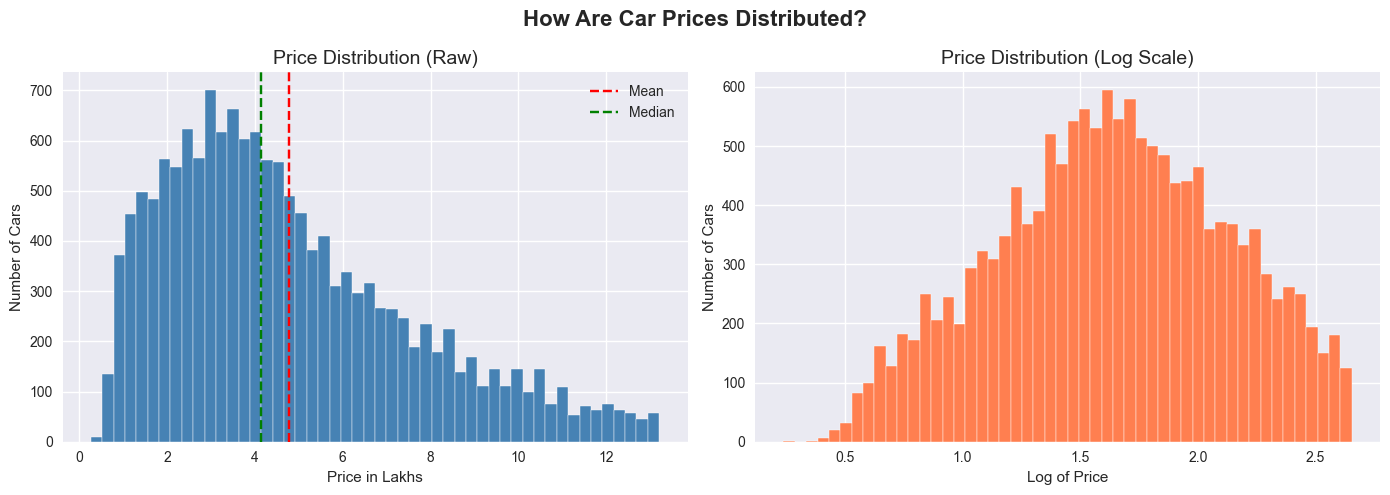

In [12]:
print("="*50)
print("PRICE ANALYSIS")
print("="*50)
print(f"Lowest Price  : ₹{df['Price_In_Lakhs'].min():.2f} Lakhs")
print(f"Highest Price : ₹{df['Price_In_Lakhs'].max():.2f} Lakhs")
print(f"Average Price : ₹{df['Price_In_Lakhs'].mean():.2f} Lakhs")
print(f"Median Price  : ₹{df['Price_In_Lakhs'].median():.2f} Lakhs")
print(f"Std Deviation : ₹{df['Price_In_Lakhs'].std():.2f} Lakhs")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['Price_In_Lakhs'], bins=50, 
             color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)', fontsize=14)
axes[0].set_xlabel('Price in Lakhs')
axes[0].set_ylabel('Number of Cars')
axes[0].axvline(df['Price_In_Lakhs'].mean(), 
                color='red', linestyle='--', label='Mean')
axes[0].axvline(df['Price_In_Lakhs'].median(), 
                color='green', linestyle='--', label='Median')
axes[0].legend()

# Log distribution
axes[1].hist(np.log1p(df['Price_In_Lakhs']), bins=50, 
             color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (Log Scale)', fontsize=14)
axes[1].set_xlabel('Log of Price')
axes[1].set_ylabel('Number of Cars')

plt.suptitle('How Are Car Prices Distributed?', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_price_distribution.png', dpi=150)
plt.show()


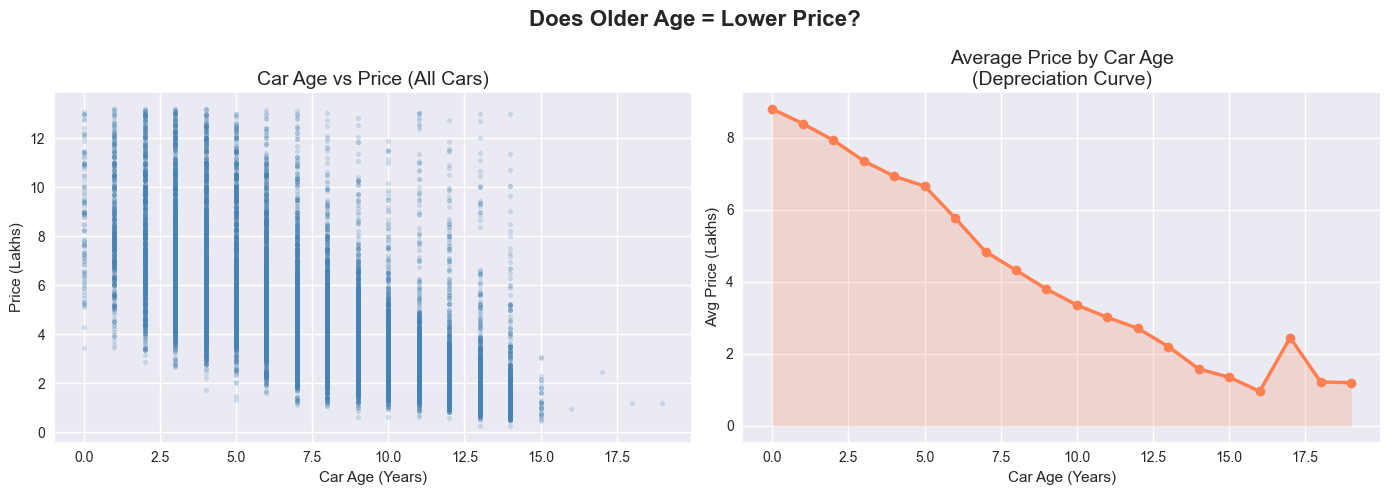

Correlation — Car Age vs Price: -0.699
Interpretation: Older car → Lower price ✅

Average price at 1 year  : ₹8.39 Lakhs
Average price at 5 years : ₹6.66 Lakhs
Average price at 10 years: ₹3.35 Lakhs

Depreciation 1→5 years   : ₹1.73 Lakhs
Depreciation 5→10 years  : ₹3.30 Lakhs


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(df['Car_Age'], df['Price_In_Lakhs'],
                alpha=0.2, color='steelblue', s=10)
axes[0].set_title('Car Age vs Price (All Cars)', fontsize=14)
axes[0].set_xlabel('Car Age (Years)')
axes[0].set_ylabel('Price (Lakhs)')

# Average price by age — the depreciation curve
avg_by_age = df.groupby('Car_Age')['Price_In_Lakhs'].mean()
axes[1].plot(avg_by_age.index, avg_by_age.values,
             marker='o', color='coral', linewidth=2.5)
axes[1].fill_between(avg_by_age.index, avg_by_age.values, 
                     alpha=0.2, color='coral')
axes[1].set_title('Average Price by Car Age\n(Depreciation Curve)', 
                  fontsize=14)
axes[1].set_xlabel('Car Age (Years)')
axes[1].set_ylabel('Avg Price (Lakhs)')

plt.suptitle('Does Older Age = Lower Price?', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_age_vs_price.png', dpi=150)
plt.show()

# Correlation
corr = df['Car_Age'].corr(df['Price_In_Lakhs'])
print(f"Correlation — Car Age vs Price: {corr:.3f}")
print("Interpretation:", 
      "Older car → Lower price ✅" if corr < 0 else "Unexpected! Check data")

# Depreciation insight
age_1 = df[df['Car_Age']==1]['Price_In_Lakhs'].mean()
age_5 = df[df['Car_Age']==5]['Price_In_Lakhs'].mean()
age_10 = df[df['Car_Age']==10]['Price_In_Lakhs'].mean()
print(f"\nAverage price at 1 year  : ₹{age_1:.2f} Lakhs")
print(f"Average price at 5 years : ₹{age_5:.2f} Lakhs")
print(f"Average price at 10 years: ₹{age_10:.2f} Lakhs")
print(f"\nDepreciation 1→5 years   : ₹{age_1 - age_5:.2f} Lakhs")
print(f"Depreciation 5→10 years  : ₹{age_5 - age_10:.2f} Lakhs")

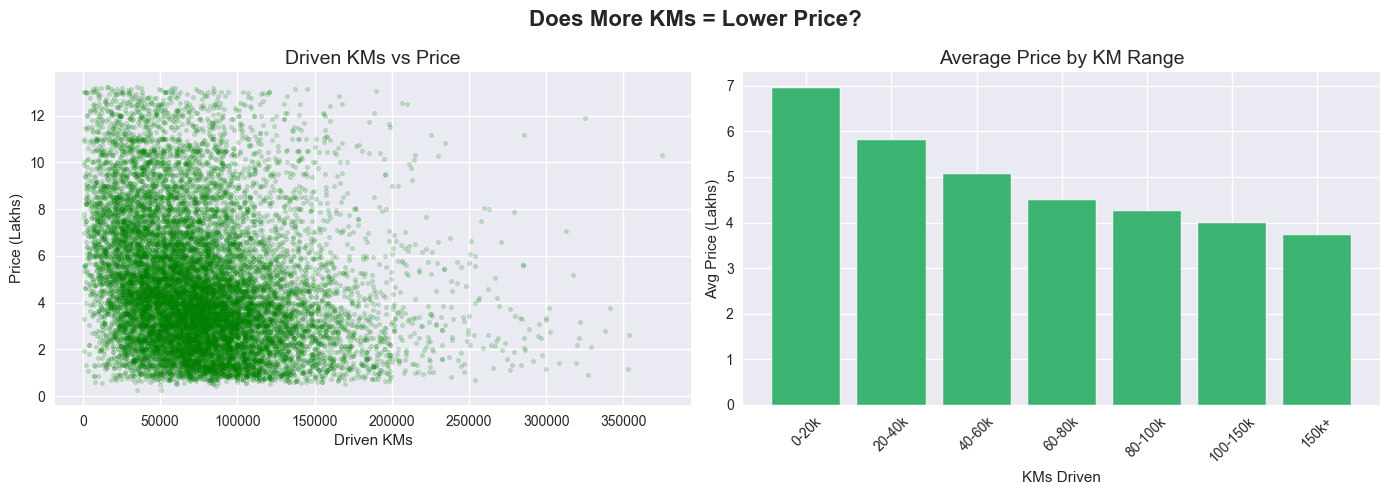

Correlation — Driven KMs vs Price: -0.255


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Driven_Kms'], df['Price_In_Lakhs'],
                alpha=0.2, color='green', s=10)
axes[0].set_title('Driven KMs vs Price', fontsize=14)
axes[0].set_xlabel('Driven KMs')
axes[0].set_ylabel('Price (Lakhs)')

# Bucket KMs into ranges
df['km_bucket'] = pd.cut(
    df['Driven_Kms'],
    bins=[0, 20000, 40000, 60000, 80000, 
          100000, 150000, 400000],
    labels=['0-20k', '20-40k', '40-60k', 
            '60-80k', '80-100k', '100-150k', '150k+']
)

avg_by_km = df.groupby('km_bucket', observed=True)['Price_In_Lakhs'].mean()
axes[1].bar(avg_by_km.index, avg_by_km.values, 
            color='mediumseagreen', edgecolor='white')
axes[1].set_title('Average Price by KM Range', fontsize=14)
axes[1].set_xlabel('KMs Driven')
axes[1].set_ylabel('Avg Price (Lakhs)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Does More KMs = Lower Price?', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('03_km_vs_price.png', dpi=150)
plt.show()

# Clean up temp column
df.drop('km_bucket', axis=1, inplace=True)

corr_km = df['Driven_Kms'].corr(df['Price_In_Lakhs'])
print(f"Correlation — Driven KMs vs Price: {corr_km:.3f}")

PETROL vs DIESEL — Statistical Test
Petrol cars : 9782 cars | Avg: ₹4.65L
Diesel cars : 3179 cars | Avg: ₹5.80L
Price difference: ₹1.15 Lakhs

T-statistic : -20.220
P-value     : 0.000000

✅ Diesel cars are statistically MORE expensive
   (p < 0.05 → This is NOT by random chance)


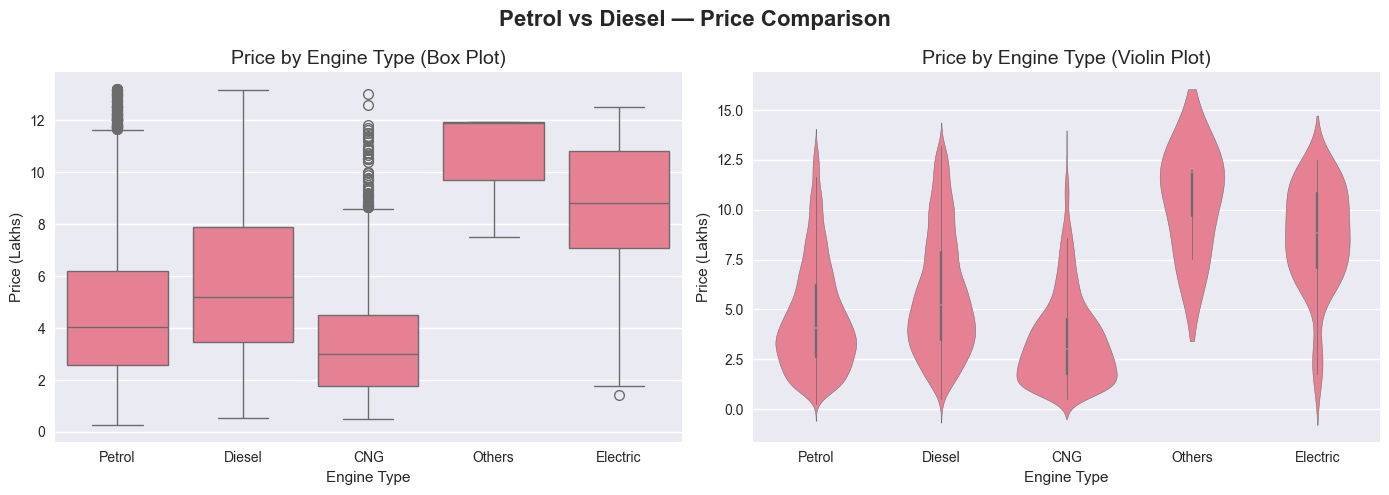

In [15]:
petrol = df[df['Engine_Type'] == 'Petrol']['Price_In_Lakhs']
diesel = df[df['Engine_Type'] == 'Diesel']['Price_In_Lakhs']

print("="*50)
print("PETROL vs DIESEL — Statistical Test")
print("="*50)
print(f"Petrol cars : {len(petrol)} cars | Avg: ₹{petrol.mean():.2f}L")
print(f"Diesel cars : {len(diesel)} cars | Avg: ₹{diesel.mean():.2f}L")
print(f"Price difference: ₹{abs(diesel.mean()-petrol.mean()):.2f} Lakhs")

# T-Test
t_stat, p_value = stats.ttest_ind(petrol, diesel)
print(f"\nT-statistic : {t_stat:.3f}")
print(f"P-value     : {p_value:.6f}")

if p_value < 0.05:
    higher = "Diesel" if diesel.mean() > petrol.mean() else "Petrol"
    print(f"\n✅ {higher} cars are statistically MORE expensive")
    print("   (p < 0.05 → This is NOT by random chance)")
else:
    print("\n❌ No significant price difference between fuel types")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Engine_Type', y='Price_In_Lakhs', 
            data=df, ax=axes[0])
axes[0].set_title('Price by Engine Type (Box Plot)', fontsize=14)
axes[0].set_xlabel('Engine Type')
axes[0].set_ylabel('Price (Lakhs)')

sns.violinplot(x='Engine_Type', y='Price_In_Lakhs', 
               data=df, ax=axes[1])
axes[1].set_title('Price by Engine Type (Violin Plot)', fontsize=14)
axes[1].set_xlabel('Engine Type')
axes[1].set_ylabel('Price (Lakhs)')

plt.suptitle('Petrol vs Diesel — Price Comparison', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('04_petrol_vs_diesel.png', dpi=150)
plt.show()

MANUAL vs AUTOMATIC — Statistical Test
Manual cars    : 11528 | Avg: ₹4.23L
Automatic cars : 3379   | Avg: ₹6.59L

P-value: 0.000000
✅ Automatic cars are statistically more expensive


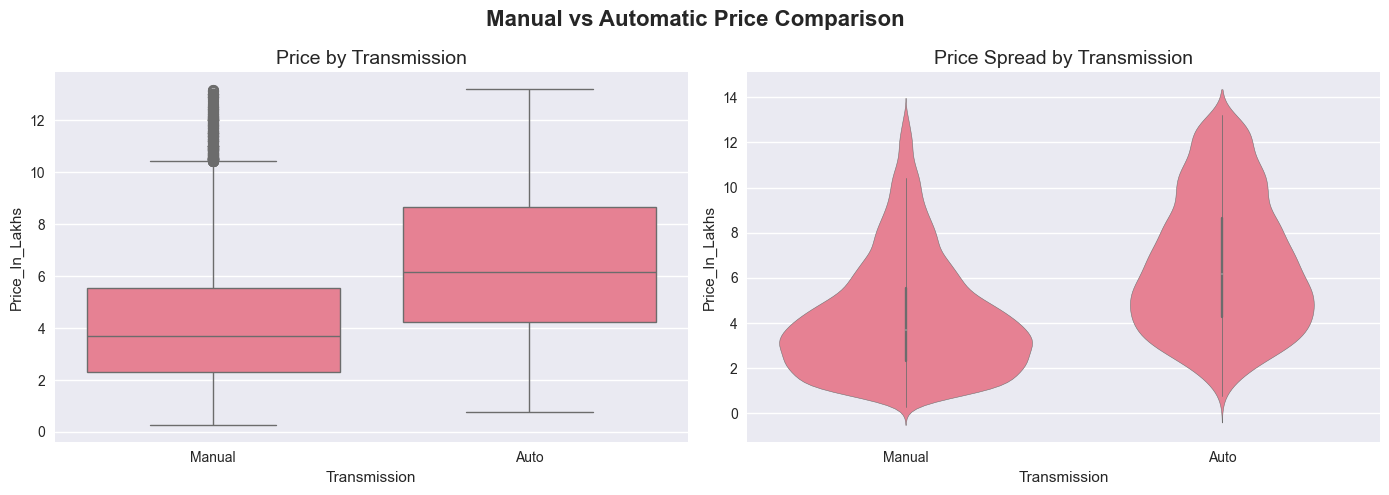

In [16]:
manual = df[df['Transmission'] == 'Manual']['Price_In_Lakhs']
auto   = df[df['Transmission'] == 'Auto']['Price_In_Lakhs']

print("="*50)
print("MANUAL vs AUTOMATIC — Statistical Test")
print("="*50)
print(f"Manual cars    : {len(manual)} | Avg: ₹{manual.mean():.2f}L")
print(f"Automatic cars : {len(auto)}   | Avg: ₹{auto.mean():.2f}L")

t_stat2, p_value2 = stats.ttest_ind(manual, auto)
print(f"\nP-value: {p_value2:.6f}")

if p_value2 < 0.05:
    higher = "Automatic" if auto.mean() > manual.mean() else "Manual"
    print(f"✅ {higher} cars are statistically more expensive")
else:
    print("❌ No significant difference")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Transmission', y='Price_In_Lakhs', 
            data=df, ax=axes[0])
axes[0].set_title('Price by Transmission', fontsize=14)

sns.violinplot(x='Transmission', y='Price_In_Lakhs', 
               data=df, ax=axes[1])
axes[1].set_title('Price Spread by Transmission', fontsize=14)

plt.suptitle('Manual vs Automatic Price Comparison', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('05_transmission_vs_price.png', dpi=150)
plt.show()

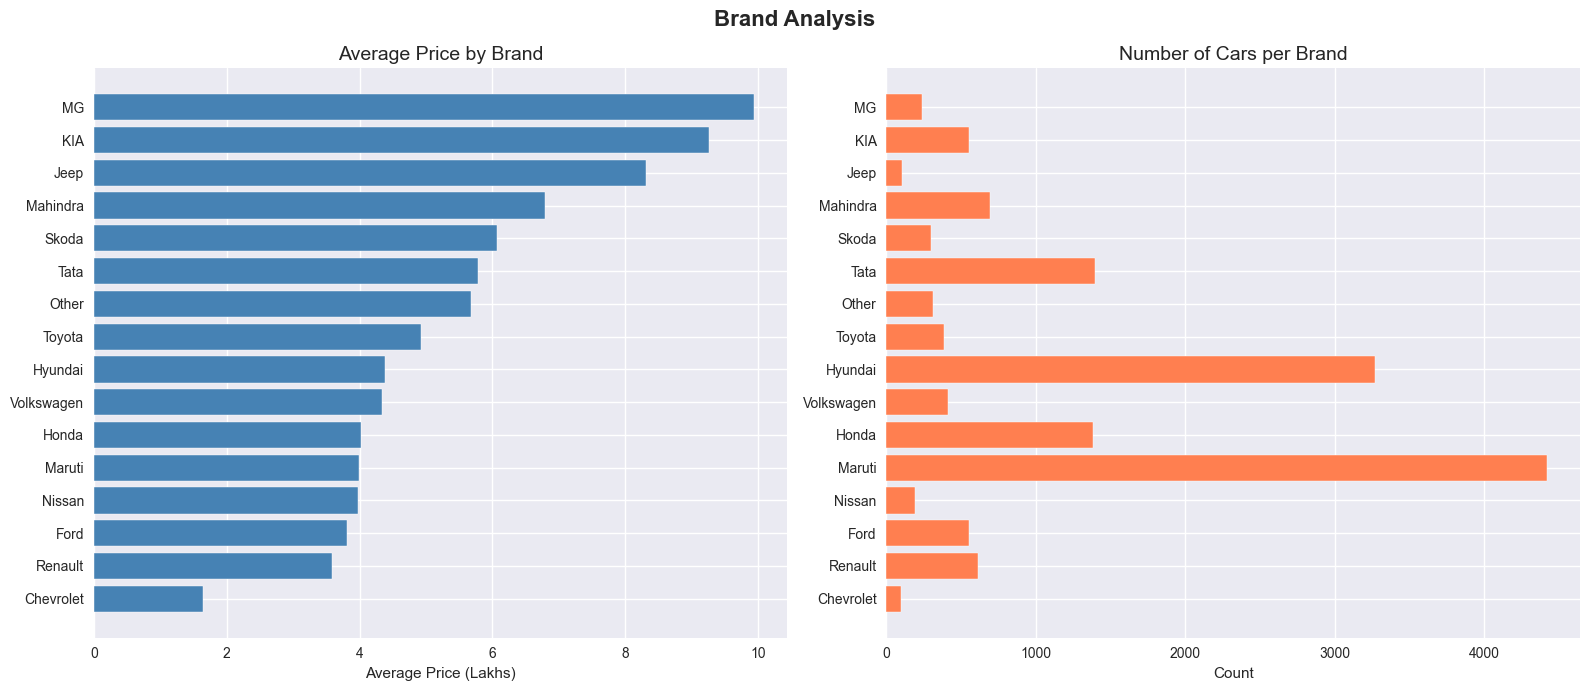


Full Brand Stats:
            Avg_Price  Count  Median
Brand                               
Chevrolet        1.64     95    1.29
Renault          3.59    614    3.17
Ford             3.81    556    3.60
Nissan           3.97    192    4.00
Maruti           3.98   4418    3.66
Honda            4.01   1383    3.68
Volkswagen       4.34    411    3.52
Hyundai          4.38   3265    3.79
Toyota           4.93    388    4.23
Other            5.68    309    5.63
Tata             5.79   1395    5.50
Skoda            6.06    296    5.63
Mahindra         6.79    690    6.74
Jeep             8.32    103    8.19
KIA              9.26    551    9.15
MG               9.95    241   10.00


In [17]:
brand_stats = df.groupby('Brand').agg(
    Avg_Price  = ('Price_In_Lakhs', 'mean'),
    Count      = ('Price_In_Lakhs', 'count'),
    Median     = ('Price_In_Lakhs', 'median')
).sort_values('Avg_Price', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Average price
axes[0].barh(brand_stats.index, brand_stats['Avg_Price'], 
             color='steelblue', edgecolor='white')
axes[0].set_title('Average Price by Brand', fontsize=14)
axes[0].set_xlabel('Average Price (Lakhs)')

# Car count
axes[1].barh(brand_stats.index, brand_stats['Count'], 
             color='coral', edgecolor='white')
axes[1].set_title('Number of Cars per Brand', fontsize=14)
axes[1].set_xlabel('Count')

plt.suptitle('Brand Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('06_brand_analysis.png', dpi=150)
plt.show()

print("\nFull Brand Stats:")
print(brand_stats.to_string())

Price by City:
           mean  median  count
Location                      
Bangalore  5.68    5.22   2362
Chennai    5.48    4.94    698
Hyderabad  5.20    4.60   1587
Pune       4.72    4.12   1396
Mumbai     4.54    3.97   1755
Delhi      4.47    3.83   5552
Ahmedabad  4.07    3.50    977
Gurgaon    3.82    3.08    580


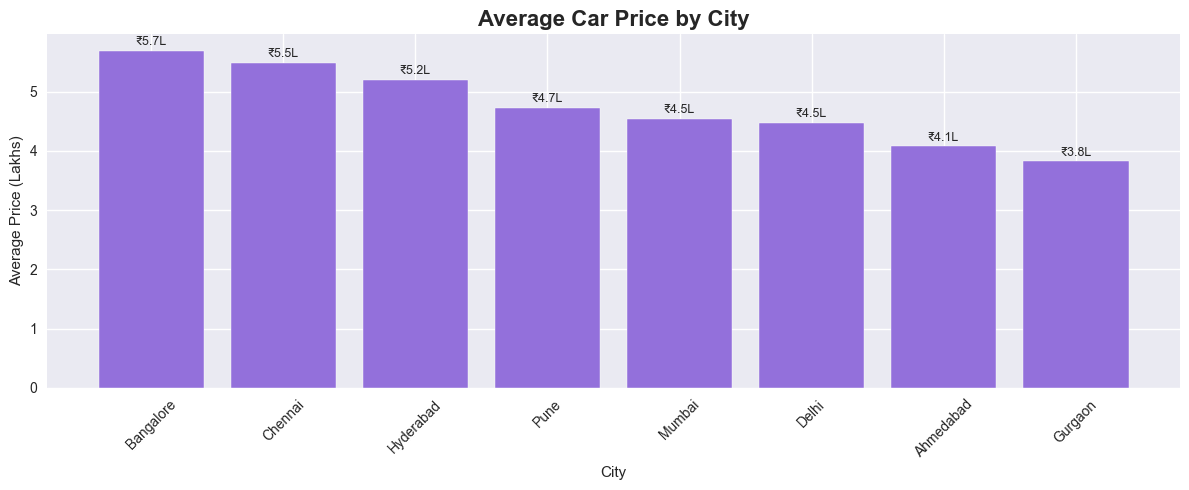

In [18]:
location_avg = df.groupby('Location')['Price_In_Lakhs'].agg(
    ['mean', 'median', 'count']
).sort_values('mean', ascending=False)

print("Price by City:")
print(location_avg.to_string())

plt.figure(figsize=(12, 5))
bars = plt.bar(location_avg.index, location_avg['mean'], 
               color='mediumpurple', edgecolor='white')
plt.title('Average Car Price by City', fontsize=16, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Average Price (Lakhs)')
plt.xticks(rotation=45)

# Add value labels
for bar, val in zip(bars, location_avg['mean']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'₹{val:.1f}L', ha='center', 
             va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('07_location_analysis.png', dpi=150)
plt.show()

In [19]:
top   = df[df['is_top_trim'] == 1]['Price_In_Lakhs']
base  = df[df['is_top_trim'] == 0]['Price_In_Lakhs']

print("="*50)
print("TOP TRIM vs BASE TRIM")
print("="*50)
print(f"Top trim  : {len(top)} cars | Avg: ₹{top.mean():.2f}L")
print(f"Base trim : {len(base)} cars | Avg: ₹{base.mean():.2f}L")
print(f"Premium for top trim: ₹{top.mean() - base.mean():.2f} Lakhs")

t3, p3 = stats.ttest_ind(top, base)
print(f"P-value: {p3:.6f}")
print("Statistically significant!" if p3 < 0.05 else "❌ Not significant")

TOP TRIM vs BASE TRIM
Top trim  : 6085 cars | Avg: ₹5.69L
Base trim : 8822 cars | Avg: ₹4.13L
Premium for top trim: ₹1.55 Lakhs
P-value: 0.000000
Statistically significant!


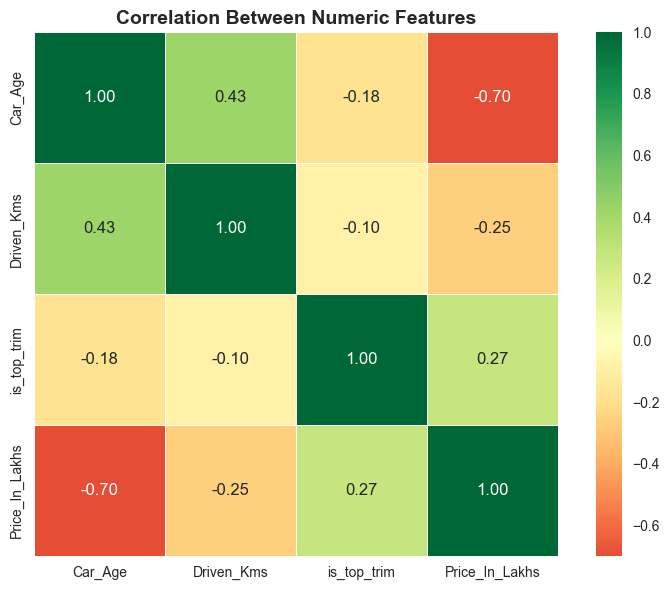


Correlations with Price:
is_top_trim    0.27
Driven_Kms    -0.25
Car_Age       -0.70


In [18]:
# Only numeric columns
num_cols = ['Car_Age', 'Driven_Kms', 'is_top_trim', 'Price_In_Lakhs']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 12}
)
plt.title('Correlation Between Numeric Features', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_correlation_heatmap.png', dpi=150)
plt.show()

print("\nCorrelations with Price:")
print(corr_matrix['Price_In_Lakhs'].drop('Price_In_Lakhs')
      .sort_values(ascending=False).to_string())

In [20]:
def check_outliers(col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    out  = df[(df[col] < low) | (df[col] > high)]
    print(f"\n{col}:")
    print(f"  Normal range : {low:.0f} → {high:.0f}")
    print(f"  Outliers     : {len(out)} rows ({len(out)/len(df)*100:.1f}%)")

for col in ['Price_In_Lakhs', 'Driven_Kms', 'Car_Age']:
    check_outliers(col)



Price_In_Lakhs:
  Normal range : -3 → 12
  Outliers     : 236 rows (1.6%)

Driven_Kms:
  Normal range : -36335 → 179865
  Outliers     : 399 rows (2.7%)

Car_Age:
  Normal range : -4 → 20
  Outliers     : 0 rows (0.0%)


In [21]:
# Remove price outliers
Q1 = df['Price_In_Lakhs'].quantile(0.25)
Q3 = df['Price_In_Lakhs'].quantile(0.75)
IQR = Q3 - Q1
df = df[
    (df['Price_In_Lakhs'] >= Q1 - 1.5*IQR) &
    (df['Price_In_Lakhs'] <= Q3 + 1.5*IQR)
]

# Remove KM outliers
Q1k = df['Driven_Kms'].quantile(0.25)
Q3k = df['Driven_Kms'].quantile(0.75)
IQRk = Q3k - Q1k
df = df[
    (df['Driven_Kms'] >= Q1k - 1.5*IQRk) &
    (df['Driven_Kms'] <= Q3k + 1.5*IQRk)
]

print(f"Final shape after outlier removal: {df.shape}")


Final shape after outlier removal: (14276, 10)


In [21]:
# Check exact counts
print(df['Engine_Type'].value_counts())

# Group small categories
major_engines = ['Petrol', 'Diesel']
df['Engine_Type'] = df['Engine_Type'].apply(
    lambda x: x if x in major_engines else 'Other'
)

print("\nAfter grouping:")
print(df['Engine_Type'].value_counts())


Engine_Type
Petrol      9583
Diesel      2846
CNG         1778
Electric      66
Others         3
Name: count, dtype: int64

After grouping:
Engine_Type
Petrol    9583
Diesel    2846
Other     1847
Name: count, dtype: int64


In [22]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
print("\nEngine_Type counts:")
print(df['Engine_Type'].value_counts())

Shape: (14276, 10)
Columns: ['Brand', 'Model', 'Engine_Type', 'Transmission', 'Driven_Kms', 'Price_In_Lakhs', 'Location', 'State', 'Car_Age', 'is_top_trim']

Missing values: 0

Engine_Type counts:
Engine_Type
Petrol      9583
Diesel      2846
CNG         1778
Electric      66
Others         3
Name: count, dtype: int64


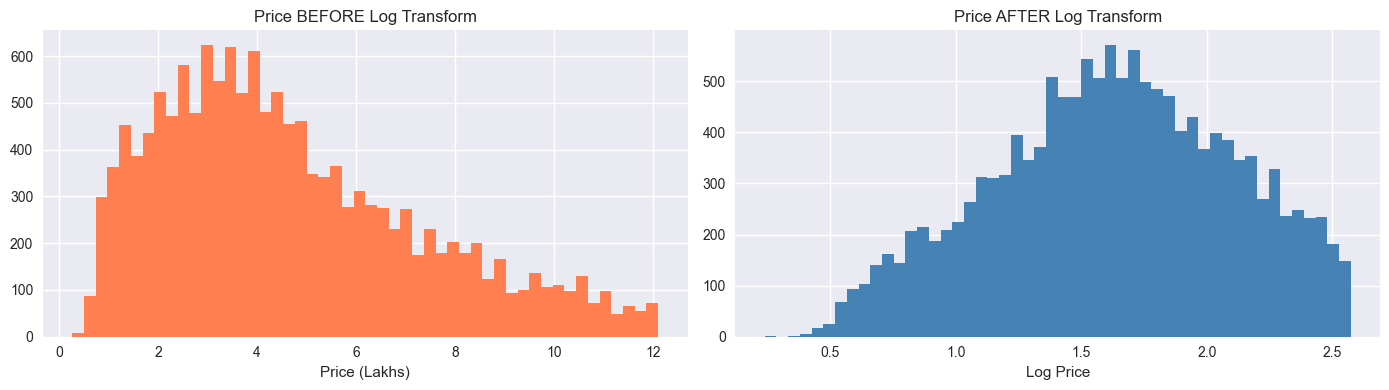

Original price range : ₹0.27 → ₹12.10 Lakhs
Log price range      : 0.239 → 2.573


In [23]:

# Before and after visual proof
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Price_In_Lakhs'], bins=50, color='coral')
axes[0].set_title('Price BEFORE Log Transform')
axes[0].set_xlabel('Price (Lakhs)')

# Apply log transform
df['Price_Log'] = np.log1p(df['Price_In_Lakhs'])

axes[1].hist(df['Price_Log'], bins=50, color='steelblue')
axes[1].set_title('Price AFTER Log Transform')
axes[1].set_xlabel('Log Price')

plt.tight_layout()
plt.show()

print(f"Original price range : ₹{df['Price_In_Lakhs'].min():.2f} → ₹{df['Price_In_Lakhs'].max():.2f} Lakhs")
print(f"Log price range      : {df['Price_Log'].min():.3f} → {df['Price_Log'].max():.3f}")

In [24]:
# X = what model LEARNS FROM
# y = what model PREDICTS

X = df.drop(['Price_In_Lakhs', 'Price_Log'], axis=1)
y = df['Price_Log']

print("Input columns:", X.columns.tolist())
print("Input shape  :", X.shape)
print("Target shape :", y.shape)


Input columns: ['Brand', 'Model', 'Engine_Type', 'Transmission', 'Driven_Kms', 'Location', 'State', 'Car_Age', 'is_top_trim']
Input shape  : (14276, 9)
Target shape : (14276,)


In [25]:
# Columns to encode
categorical_cols = ['Brand', 'Model', 'Engine_Type', 
                    'Transmission', 'Location', 'State']

# Check unique values before encoding
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")


Brand: 16 unique values
Model: 94 unique values
Engine_Type: 5 unique values
Transmission: 2 unique values
Location: 8 unique values
State: 16 unique values


In [26]:
# Apply One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True    # Avoids duplicate information
)

print("\nShape BEFORE encoding: (14800, 9)")
print(f"Shape AFTER encoding : {X.shape}")
print(f"\nTotal features now   : {X.shape[1]}")
print("\nAll columns after encoding:")
print(X.columns.tolist())



Shape BEFORE encoding: (14800, 9)
Shape AFTER encoding : (14276, 138)

Total features now   : 138

All columns after encoding:
['Driven_Kms', 'Car_Age', 'is_top_trim', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Jeep', 'Brand_KIA', 'Brand_MG', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Nissan', 'Brand_Other', 'Brand_Renault', 'Brand_Skoda', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Model_ASTOR', 'Model_AURA', 'Model_Alto', 'Model_Alto 800', 'Model_Alto K10', 'Model_Amaze', 'Model_Ameo', 'Model_BR-V', 'Model_BREZZA', 'Model_Baleno', 'Model_Beat', 'Model_Brio', 'Model_CARENS', 'Model_Celerio', 'Model_Ciaz', 'Model_City', 'Model_Compass', 'Model_Corolla Altis', 'Model_Creta', 'Model_Duster', 'Model_Dzire', 'Model_Ecosport', 'Model_Eeco', 'Model_Elite i20', 'Model_Eon', 'Model_Ertiga', 'Model_Etios', 'Model_Etios Liva', 'Model_FRONX', 'Model_Figo', 'Model_Figo Aspire', 'Model_GRAND I10 NIOS', 'Model_Glanza', 'Model_Grand Vitara', 'Model_Grand i10', 'Model_HECTOR', 'Model_H

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,    # 80% train, 20% test
    random_state=42   # Same split every time you run
)


print("TRAIN-TEST SPLIT RESULTS")

print(f"Total records    : {len(X)}")
print(f"Training records : {len(X_train)}  (80%)")
print(f"Testing records  : {len(X_test)}   (20%)")
print(f"Total features   : {X_train.shape[1]}")


TRAIN-TEST SPLIT RESULTS
Total records    : 14276
Training records : 11420  (80%)
Testing records  : 2856   (20%)
Total features   : 138


In [30]:
scaler = StandardScaler()

# CRITICAL RULE — never forget this:
# fit_transform on TRAIN → learns scale from training data
# transform only on TEST → applies same scale (never relearn!)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete!")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape : {X_test_scaled.shape}")

# Verify scaling worked
print(f"\nBefore scaling — Driven_Kms mean: {X_train['Driven_Kms'].mean():.0f}")
print(f"After scaling  — Mean ≈ 0, Std ≈ 1 (standardized)")


Scaling complete!
X_train shape: (11420, 138)
X_test shape : (2856, 138)

Before scaling — Driven_Kms mean: 72905
After scaling  — Mean ≈ 0, Std ≈ 1 (standardized)


In [31]:
# Save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# Save column names — VERY IMPORTANT for web app
column_names = X.columns.tolist()
pickle.dump(column_names, open('model_columns.pkl', 'wb'))

# Save train/test data for Stage 5
np.save('X_train.npy', X_train_scaled)
np.save('X_test.npy',  X_test_scaled)
np.save('y_train.npy', y_train.values)
np.save('y_test.npy',  y_test.values)

print("Files saved:")
print("   → scaler.pkl")
print("   → model_columns.pkl")
print("   → X_train.npy")
print("   → X_test.npy")
print("   → y_train.npy")
print("   → y_test.npy")

Files saved:
   → scaler.pkl
   → model_columns.pkl
   → X_train.npy
   → X_test.npy
   → y_train.npy
   → y_test.npy


In [32]:
# Check if this is an issue
print("Rows lost:", 14800 - 14276)  # = 524 rows

# Find where they went
for col in ['Brand', 'Model', 'Engine_Type', 
            'Transmission', 'Location', 'State']:
    print(f"{col} nulls: {df[col].isnull().sum()}")

Rows lost: 524
Brand nulls: 0
Model nulls: 0
Engine_Type nulls: 0
Transmission nulls: 0
Location nulls: 0
State nulls: 0


In [33]:

# Load everything saved in Stage 4
X_train = np.load('X_train.npy')
X_test  = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_test  = np.load('y_test.npy')

print("Data loaded successfully!")
print(f"X_train : {X_train.shape}")   # (11420, 136)
print(f"X_test  : {X_test.shape}")    # (2856, 136)
print(f"y_train : {y_train.shape}")   # (11420,)
print(f"y_test  : {y_test.shape}")    # (2856,)

Data loaded successfully!
X_train : (11420, 138)
X_test  : (2856, 138)
y_train : (11420,)
y_test  : (2856,)


In [34]:
def evaluate_model(name, y_true_log, y_pred_log):
    """
    Takes log-scale predictions,
    converts back to Lakhs,
    then measures accuracy
    """
    # Convert from log scale back to actual Lakhs
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAE   : ₹{mae:.4f} Lakhs")
    print(f"         (avg prediction is off by ₹{mae:.2f}L)")
    print(f"  MAPE  : {mape:.2f}%")
    print(f"         (avg % error per prediction)")
    print(f"  R²    : {r2:.4f}  ({r2*100:.1f}%)")
    print(f"         (model explains {r2*100:.1f}% of price variation)")

    if r2 >= 0.90:
        print("  Verdict :  Excellent!")
    elif r2 >= 0.80:
        print("  Verdict :  Good")
    elif r2 >= 0.70:
        print("  Verdict :  Acceptable")
    else:
        print("  Verdict :  Needs Improvement")

    return mae, r2, mape


In [35]:
print("\n Training Linear Regression...")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression trained!")
lr_mae, lr_r2, lr_mape = evaluate_model(
    "Linear Regression", y_test, lr_pred
)


 Training Linear Regression...
Linear Regression trained!

  Linear Regression
  MAE   : ₹0.6167 Lakhs
         (avg prediction is off by ₹0.62L)
  MAPE  : 14.83%
         (avg % error per prediction)
  R²    : 0.8710  (87.1%)
         (model explains 87.1% of price variation)
  Verdict :  Good


In [36]:
print("\n Training Random Forest...")
print("    (This takes 1-3 minutes — normal!)")

rf_model = RandomForestRegressor(
    n_estimators=200,     # 200 decision trees
    max_depth=15,         # Each tree can go 15 levels deep
    min_samples_split=5,  # Need 5+ samples to split a node
    min_samples_leaf=2,   # Each leaf needs 2+ samples
    random_state=42,
    n_jobs=-1             # Use ALL CPU cores → faster training
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest trained!")
rf_mae, rf_r2, rf_mape = evaluate_model(
    "Random Forest", y_test, rf_pred
)



 Training Random Forest...
    (This takes 1-3 minutes — normal!)
Random Forest trained!

  Random Forest
  MAE   : ₹0.7348 Lakhs
         (avg prediction is off by ₹0.73L)
  MAPE  : 17.03%
         (avg % error per prediction)
  R²    : 0.8358  (83.6%)
         (model explains 83.6% of price variation)
  Verdict :  Good


In [37]:
print("\n Training XGBoost...")

xgb_model = XGBRegressor(
    n_estimators=500,        # 500 trees built sequentially
    learning_rate=0.05,      # Each tree corrects 5% of error
    max_depth=6,             # Controlled tree depth
    subsample=0.8,           # Each tree uses 80% of rows
    colsample_bytree=0.8,    # Each tree uses 80% of features
    min_child_weight=3,      # Minimum samples in leaf
    reg_alpha=0.1,           # L1 regularization (prevents overfitting)
    reg_lambda=1.0,          # L2 regularization (prevents overfitting)
    random_state=42,
    n_jobs=-1,
    verbosity=0              # Silent mode
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100              # Print score every 100 rounds
)

xgb_pred = xgb_model.predict(X_test)

print("\n XGBoost trained!")
xgb_mae, xgb_r2, xgb_mape = evaluate_model(
    "XGBoost", y_test, xgb_pred
)



 Training XGBoost...
[0]	validation_0-rmse:0.45785


[100]	validation_0-rmse:0.16941
[200]	validation_0-rmse:0.14796
[300]	validation_0-rmse:0.13860
[400]	validation_0-rmse:0.13251
[499]	validation_0-rmse:0.12775

 XGBoost trained!

  XGBoost
  MAE   : ₹0.5452 Lakhs
         (avg prediction is off by ₹0.55L)
  MAPE  : 12.68%
         (avg % error per prediction)
  R²    : 0.9036  (90.4%)
         (model explains 90.4% of price variation)
  Verdict :  Excellent!


In [38]:
print("\n" + "="*50)
print("  FINAL MODEL COMPARISON")
print("="*50)
print(f"{'Model':<22} {'MAE (₹L)':<12} {'MAPE %':<12} {'R²':<10}")
print("-"*56)
print(f"{'Linear Regression':<22} {lr_mae:<12.4f} {lr_mape:<12.2f} {lr_r2:<10.4f}")
print(f"{'Random Forest':<22} {rf_mae:<12.4f} {rf_mape:<12.2f} {rf_r2:<10.4f}")
print(f"{'XGBoost':<22} {xgb_mae:<12.4f} {xgb_mape:<12.2f} {xgb_r2:<10.4f}")
print("="*50)

# Pick the best model automatically
models = {
    'Linear Regression': (lr_r2, lr_model, lr_pred),
    'Random Forest':     (rf_r2, rf_model, rf_pred),
    'XGBoost':           (xgb_r2, xgb_model, xgb_pred)
}
best_name = max(models, key=lambda x: models[x][0])
best_r2, best_model, best_pred = models[best_name]

print(f"\n🏆 Best Model: {best_name}")
print(f"   R² Score  : {best_r2:.4f}")


  FINAL MODEL COMPARISON
Model                  MAE (₹L)     MAPE %       R²        
--------------------------------------------------------
Linear Regression      0.6167       14.83        0.8710    
Random Forest          0.7348       17.03        0.8358    
XGBoost                0.5452       12.68        0.9036    

🏆 Best Model: XGBoost
   R² Score  : 0.9036


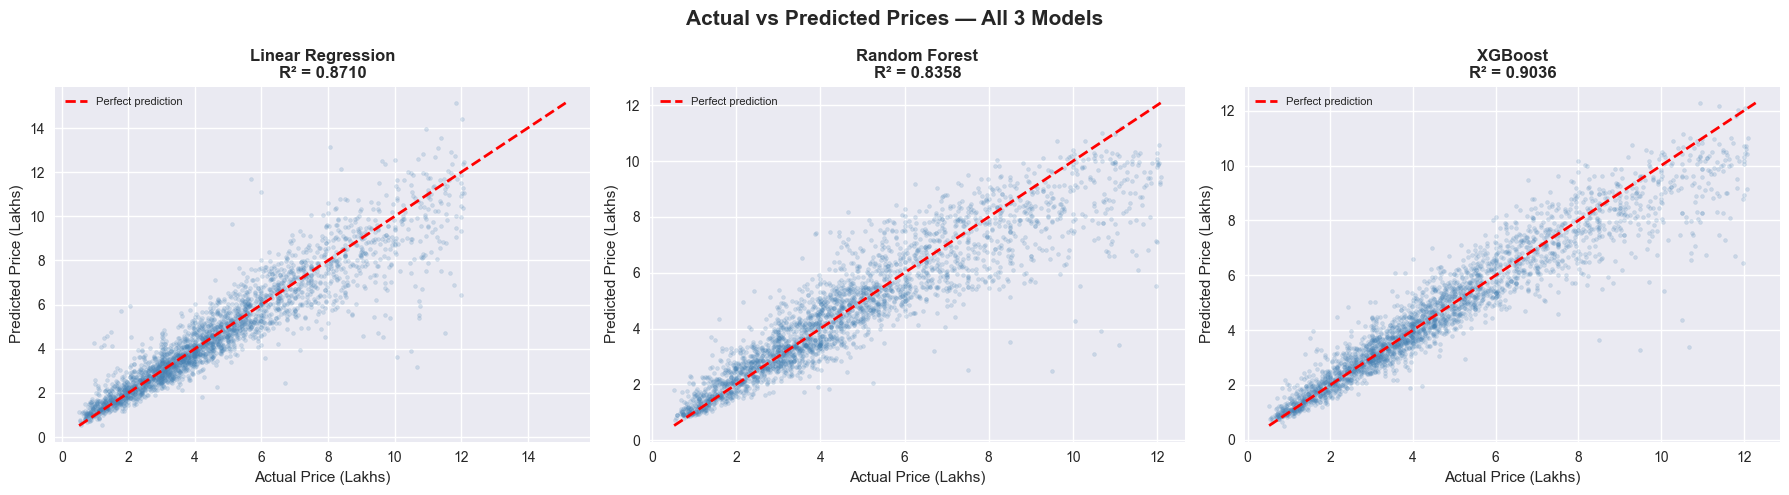

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_results = [
    ("Linear Regression", lr_pred,  lr_r2),
    ("Random Forest",     rf_pred,  rf_r2),
    ("XGBoost",           xgb_pred, xgb_r2),
]

y_actual = np.expm1(y_test)

for ax, (name, pred_log, r2) in zip(axes, model_results):
    pred_actual = np.expm1(pred_log)

    ax.scatter(y_actual, pred_actual, 
               alpha=0.2, s=8, color='steelblue')

    # Perfect prediction line
    min_val = min(y_actual.min(), pred_actual.min())
    max_val = max(y_actual.max(), pred_actual.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=2, label='Perfect prediction')

    ax.set_title(f'{name}\nR² = {r2:.4f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Price (Lakhs)')
    ax.set_ylabel('Predicted Price (Lakhs)')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Prices — All 3 Models',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()


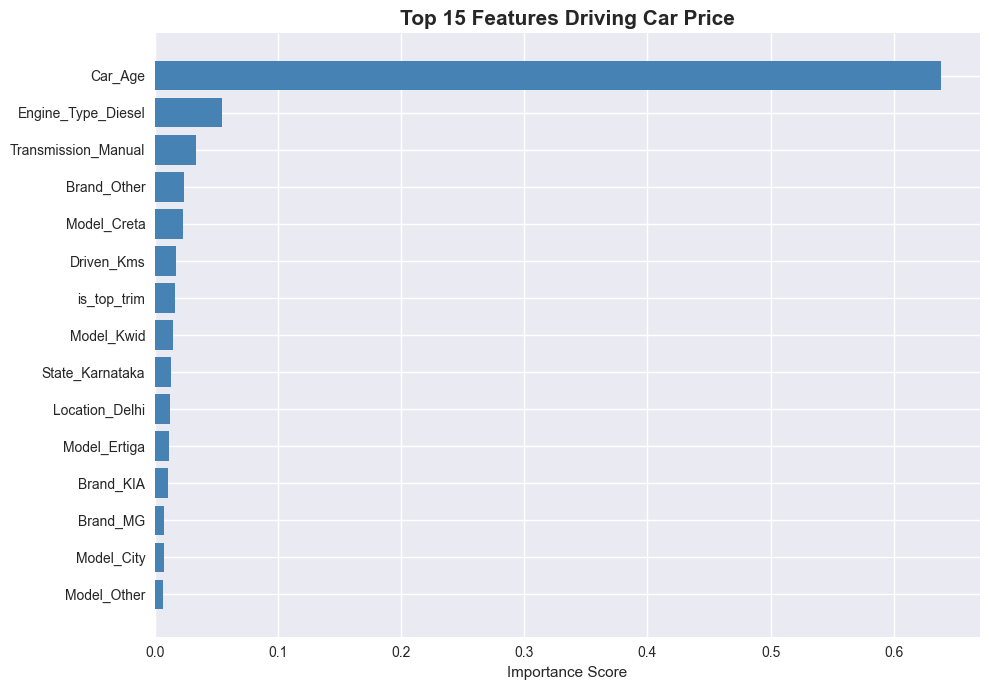


Top 10 Price Drivers:
            Feature  Importance
            Car_Age        0.64
 Engine_Type_Diesel        0.05
Transmission_Manual        0.03
        Brand_Other        0.02
        Model_Creta        0.02
         Driven_Kms        0.02
        is_top_trim        0.02
         Model_Kwid        0.01
    State_Karnataka        0.01
     Location_Delhi        0.01


In [40]:
# Load column names
model_columns = pickle.load(open('model_columns.pkl', 'rb'))

# Get feature importances from Random Forest
rf_importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature':    model_columns,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(feat_df['Feature'][::-1], 
         feat_df['Importance'][::-1], 
         color='steelblue')
plt.title('Top 15 Features Driving Car Price',
          fontsize=15, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 Price Drivers:")
print(feat_df.head(10).to_string(index=False))


In [41]:
# Let's test with the first car in your dataset:
# KIA SONET, Petrol, Manual, 2022, 43,447 km, Delhi
# Real price: ₹6.21 Lakhs

y_actual_all  = np.expm1(y_test)
y_pred_best   = np.expm1(best_pred)

# Show first 10 predictions vs actual
print("\nSample Predictions vs Actual:")
print(f"{'Actual (₹L)':<15} {'Predicted (₹L)':<18} {'Error (₹L)':<12}")
print("-"*45)
for actual, predicted in zip(y_actual_all[:10], y_pred_best[:10]):
    error = abs(actual - predicted)
    print(f"₹{actual:<14.2f} ₹{predicted:<17.2f} ₹{error:.2f}")


Sample Predictions vs Actual:
Actual (₹L)     Predicted (₹L)     Error (₹L)  
---------------------------------------------
₹4.40           ₹4.25              ₹0.15
₹8.23           ₹5.96              ₹2.27
₹1.00           ₹1.53              ₹0.53
₹2.78           ₹2.75              ₹0.03
₹2.04           ₹1.86              ₹0.18
₹2.79           ₹3.10              ₹0.31
₹7.09           ₹8.26              ₹1.17
₹5.82           ₹6.19              ₹0.37
₹8.65           ₹8.82              ₹0.17
₹4.56           ₹4.45              ₹0.11


In [42]:

# Save best model
pickle.dump(best_model, open('best_model.pkl', 'wb'))

# Also save all 3 for comparison
pickle.dump(lr_model,  open('lr_model.pkl',  'wb'))
pickle.dump(rf_model,  open('rf_model.pkl',  'wb'))
pickle.dump(xgb_model, open('xgb_model.pkl', 'wb'))

print(" All models saved!")
print(f"\n Best model → best_model.pkl")
print(f"   This is your: {best_name}")
print(f"   R² Score    : {best_r2:.4f}")
print(f"   Ready for deployment!")


 All models saved!

 Best model → best_model.pkl
   This is your: XGBoost
   R² Score    : 0.9036
   Ready for deployment!
